# Hyperliquid Trader Behavior vs Bitcoin Market Sentiment Analysis

## Objective
The objective of this analysis is to study how Bitcoin market sentiment
(Fear / Greed Index) affects trader behavior and performance on Hyperliquid.

This notebook covers:
- Data cleaning and preparation
- Performance analysis across market sentiment
- Behavioral segmentation of traders
- Actionable strategy recommendations
- Bonus predictive modeling

# Part A — Data Preparation

In this section, I load both datasets, check for missing values and duplicates,
convert timestamps into proper datetime format, and align both datasets
at daily level using the trade date.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

In [2]:
sentiment_df = pd.read_csv("fear_greed_index.csv")
trades_df = pd.read_csv("historical_data.csv")

print("Sentiment shape:", sentiment_df.shape)
print("Trades shape:", trades_df.shape)

sentiment_df.head()

Sentiment shape: (2644, 4)
Trades shape: (211224, 16)


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [3]:
trades_df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [5]:
sentiment_df['date'] = pd.to_datetime(sentiment_df['date'])

trades_df['trade_date'] = pd.to_datetime(
    trades_df['Timestamp'],
    unit='ms')

trades_df['trade_date'] = trades_df['trade_date'].dt.date
sentiment_df['date'] = sentiment_df['date'].dt.date

sentiment_df.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [4]:
print("Sentiment Missing Values")
print(sentiment_df.isnull().sum())

print("\nTrades Missing Values")
print(trades_df.isnull().sum())

print("\nDuplicates in sentiment:", sentiment_df.duplicated().sum())
print("Duplicates in trades:", trades_df.duplicated().sum())

Sentiment Missing Values
timestamp         0
value             0
classification    0
date              0
dtype: int64

Trades Missing Values
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Duplicates in sentiment: 0
Duplicates in trades: 0


### Observation
The sentiment dataset contains daily Bitcoin Fear & Greed labels,
while the Hyperliquid dataset contains trade-level transaction records.

Both datasets were aligned using daily dates.

In [6]:
merged_df = pd.merge(
    trades_df,
    sentiment_df[['date', 'classification']],
    left_on='trade_date',
    right_on='date',
    how='left'
)

print("Merged shape:", merged_df.shape)
merged_df.head()

Merged shape: (211224, 19)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,trade_date,date,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-10-27,2024-10-27,Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-10-27,2024-10-27,Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-10-27,2024-10-27,Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-10-27,2024-10-27,Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-10-27,2024-10-27,Greed


### Merge Validation
After merging, only rows with valid sentiment labels were retained
for further analysis.

Extreme Fear dates were not present in the final analysis data
because no trade records overlapped with those dates.

In [7]:
analysis_df = merged_df.dropna(
    subset=['classification']).copy()

print("Analysis shape:", analysis_df.shape)

Analysis shape: (184263, 19)


In [8]:
analysis_df['classification'].value_counts()

classification
Fear             133871
Greed             36289
Neutral            7141
Extreme Greed      6962
Name: count, dtype: int64

### Extreme Fear not present because no overlapping trade dates exist.

In [9]:
sentiment_order = [
    'Fear',
    'Neutral',
    'Greed',
    'Extreme Greed'
]

analysis_df['classification'] = pd.Categorical(
    analysis_df['classification'],
    categories=sentiment_order,
    ordered=True
)

In [10]:
daily_metrics = analysis_df.groupby(
    ['Account', 'trade_date', 'classification']
).agg({
    'Closed PnL': 'sum',
    'Size USD': 'mean',
    'Side': 'count',
    'Start Position': 'mean'
}).reset_index()

daily_metrics.columns = [
    'account',
    'date',
    'classification',
    'daily_pnl',
    'avg_trade_size_usd',
    'num_trades',
    'avg_position'
]

daily_metrics.head()

C:\Users\reddy\AppData\Local\Temp\ipykernel_28776\618179423.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  daily_metrics = analysis_df.groupby(


,account,date,classification,daily_pnl,avg_trade_size_usd,num_trades,avg_position
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2023-03-28,Fear,0.0,NaN,0,NaN
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2023-03-28,Neutral,0.0,NaN,0,NaN
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2023-03-28,Greed,0.0,NaN,0,NaN
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2023-03-28,Extreme Greed,0.0,NaN,0,NaN
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2023-11-14,Fear,0.0,NaN,0,NaN


In [11]:
daily_metrics['risk_ratio'] = (
    daily_metrics['avg_position'].abs() /
    (daily_metrics['avg_trade_size_usd'].abs() + 1)
)

daily_metrics.head()

,account,date,classification,daily_pnl,avg_trade_size_usd,num_trades,avg_position,risk_ratio
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2023-03-28,Fear,0.0,NaN,0,NaN,NaN
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2023-03-28,Neutral,0.0,NaN,0,NaN,NaN
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2023-03-28,Greed,0.0,NaN,0,NaN,NaN
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2023-03-28,Extreme Greed,0.0,NaN,0,NaN,NaN
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2023-11-14,Fear,0.0,NaN,0,NaN,NaN


# Part B — Analysis

In [12]:
performance_by_sentiment = analysis_df.groupby('classification').agg(
    total_pnl=('Closed PnL', 'sum'),
    avg_pnl=('Closed PnL', 'mean'),
    median_pnl=('Closed PnL', 'median'),
    pnl_std=('Closed PnL', 'std'),
    win_rate=('Closed PnL', lambda x: (x > 0).mean()),
    trade_count=('Closed PnL', 'count')
).reset_index()

performance_by_sentiment

C:\Users\reddy\AppData\Local\Temp\ipykernel_28776\3812692459.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  performance_by_sentiment = analysis_df.groupby('classification').agg(


,classification,total_pnl,avg_pnl,median_pnl,pnl_std,win_rate,trade_count
0,Fear,6.699925e+06,50.047622,0.0,909.121796,0.415146,133871
1,Neutral,1.587424e+05,22.229713,0.0,633.704815,0.317182,7141
2,Greed,3.189617e+06,87.894859,0.0,1148.343968,0.446471,36289
3,Extreme Greed,1.769655e+05,25.418772,0.0,306.166937,0.490089,6962


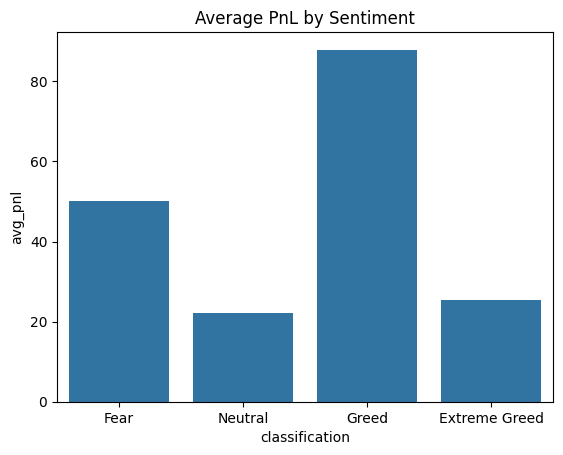

In [13]:
sns.barplot(
    data=performance_by_sentiment,
    x='classification',
    y='avg_pnl'
)

plt.title("Average PnL by Sentiment")
plt.show()

### Insight 1 — Profitability by Sentiment

The plot shows clear variation in average profitability across
different sentiment regimes.

The highest average PnL is observed during **Greed** periods,
indicating that traders tend to perform best in moderately bullish conditions.

Interestingly, **Fear** days also show relatively strong average PnL,
which may suggest increased volatility creates more short-term
trading opportunities.

In contrast, **Neutral** and **Extreme Greed** periods show lower
average profitability.

During Extreme Greed periods,
market moves may already be overextended, leading to
reduced edge and lower trade profitability.

### Strategy Recommendation Based on PnL Trend

Trading performance appears strongest during **Greed** and **Fear**
regimes rather than **Extreme Greed**.

This suggests that traders may benefit from participating
during moderately directional markets while avoiding
overextended greedy conditions.

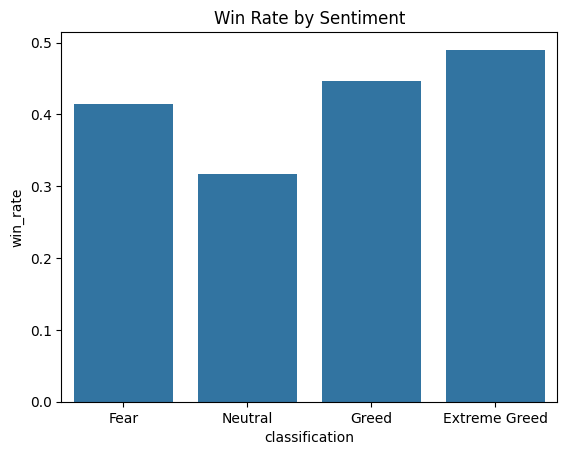

In [14]:
sns.barplot(
    data=performance_by_sentiment,
    x='classification',
    y='win_rate'
)

plt.title("Win Rate by Sentiment")
plt.show()

### Insight 2 — Win Rate by Sentiment

The highest win rate is observed during **Extreme Greed** periods,
followed by **Greed**.

This indicates that traders are more likely to have profitable trades
during bullish sentiment conditions.

Although **Extreme Greed** has the highest win rate,
the **highest average PnL occurs during Greed**.

This suggests that while traders win more often in Extreme Greed,
the magnitude of profits is higher during Greed periods.

### Strategy Recommendation

For frequent traders, **Greed periods may offer better risk-reward**
than Extreme Greed.

Extreme Greed can be suitable for short-duration trades with
tight profit targets, while Greed may support larger directional moves.

## Question 1:
Does trader performance differ across market sentiment regimes?

## Answer 
Yes, trader performance differs significantly by sentiment.

- **Greed** : highest average profitability
- **Extreme Greed** : highest win rate
- **Fear** : strong average returns with high volatility
- **Neutral** : weakest regime

This confirms that market sentiment materially impacts
trader performance.

In [15]:
behavior_by_sentiment = analysis_df.groupby('classification').agg(
    avg_trade_size=('Size USD', 'mean'),
    avg_position=('Start Position', 'mean'),
    avg_pnl=('Closed PnL', 'mean'),
    trades=('Account', 'count')
).reset_index()

behavior_by_sentiment

C:\Users\reddy\AppData\Local\Temp\ipykernel_28776\3331718602.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  behavior_by_sentiment = analysis_df.groupby('classification').agg(


,classification,avg_trade_size,avg_position,avg_pnl,trades
0,Fear,5259.977837,13170.980222,50.047622,133871
1,Neutral,3058.848110,5895.819177,22.229713,7141
2,Greed,3182.883845,19741.005986,87.894859,36289
3,Extreme Greed,5660.265764,70307.280908,25.418772,6962


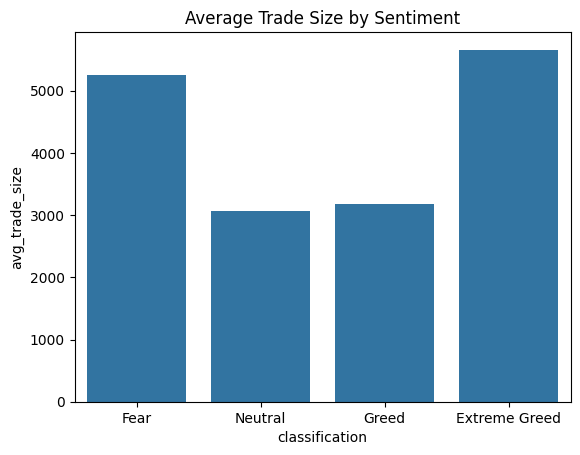

In [16]:
sns.barplot(
    data=behavior_by_sentiment,
    x='classification',
    y='avg_trade_size'
)

plt.title("Average Trade Size by Sentiment")
plt.show()

### Insight 3 — Average Trade Size by Sentiment

The average trade size is highest during **Extreme Greed**,
followed by **Fear**.

This suggests that traders take **larger positions during strong emotional market regimes**,
whether driven by optimism (Extreme Greed) or panic/opportunity (Fear).

In contrast, **Neutral** and **Greed** periods show smaller average trade sizes.

This behavior indicates that traders tend to increase position size
when market conviction is stronger.

During Extreme Greed, traders may be more confident in trend continuation,
while during Fear, larger positions may reflect volatility-driven opportunities
or aggressive dip-buying / short-selling.

### Strategy Recommendation

During **Extreme Greed**, traders should monitor position sizing carefully.

Despite larger average trade sizes and higher win rate,
the overall average PnL is lower than Greed,
indicating possible overexposure or reduced risk-reward.

In [17]:
long_short_analysis = analysis_df.groupby(
    ['classification', 'Side']
).size().reset_index(name='count')

long_short_analysis

C:\Users\reddy\AppData\Local\Temp\ipykernel_28776\1167059473.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  long_short_analysis = analysis_df.groupby(


,classification,Side,count
0,Fear,BUY,66081
1,Fear,SELL,67790
2,Neutral,BUY,3505
3,Neutral,SELL,3636
4,Greed,BUY,15421
5,Greed,SELL,20868
6,Extreme Greed,BUY,3371
7,Extreme Greed,SELL,3591


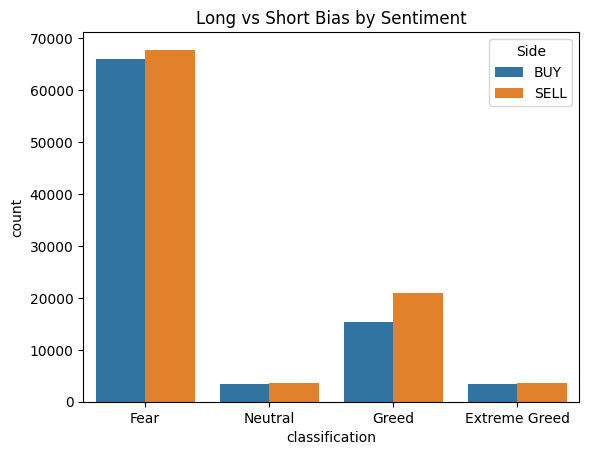

In [18]:
sns.barplot(
    data=long_short_analysis,
    x='classification',
    y='count',
    hue='Side'
)

plt.title("Long vs Short Bias by Sentiment")
plt.show()

### Insight 4 — Long vs Short Bias by Sentiment

The plot shows that **SELL trades consistently exceed BUY trades**
across most sentiment regimes.

This is particularly noticeable during **Greed** periods,
where SELL positions significantly outnumber BUY positions.

In [25]:
trade_frequency = analysis_df.groupby(
    'classification',
    observed=True
).size().reset_index(name='trade_count')

trade_frequency

,classification,trade_count
0,Fear,133871
1,Neutral,7141
2,Greed,36289
3,Extreme Greed,6962


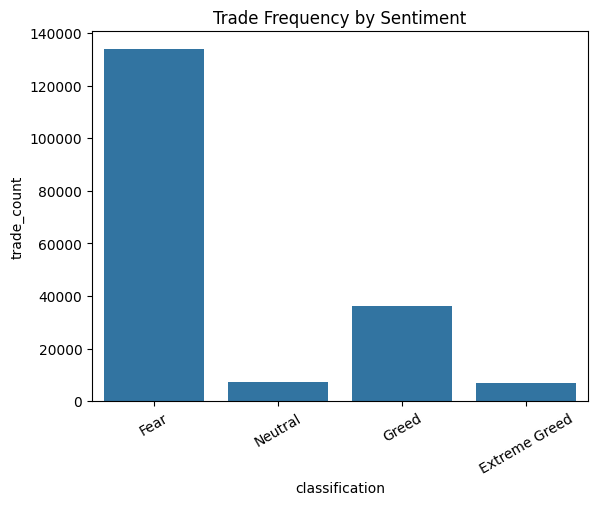

In [26]:
sns.barplot(
    data=trade_frequency,
    x='classification',
    y='trade_count'
)

plt.title("Trade Frequency by Sentiment")
plt.xticks(rotation=30)
plt.show()

### Insight 5 — Trade Frequency by Sentiment

Trading activity is heavily concentrated during **Fear** periods.

The number of trades executed during Fear is significantly higher
than all other sentiment regimes combined.

This strongly suggests that traders become far more active
during uncertain or volatile market conditions.

A possible explanation is that Fear periods create higher volatility,
leading to more entry and exit opportunities.

This may also reflect panic-driven trading,
rapid position adjustments, or short-term speculative activity.

### Strategy Recommendation

During **Fear** periods, traders may benefit from
higher-frequency short-term strategies,
provided strict risk controls are applied.

These periods show significantly higher activity
and strong profit opportunities.

## Q2. Do traders change behavior based on sentiment?\

## Answer 

Yes, traders clearly change behavior based on sentiment.

Observed changes include:
- larger trade sizes during Extreme Greed and Fear
- highest trade activity during Fear
- SELL bias during Greed
- stronger directional conviction during emotional regimes

In [19]:
trader_segments = analysis_df.groupby('Account').agg(
    total_pnl=('Closed PnL', 'sum'),
    avg_pnl=('Closed PnL', 'mean'),
    avg_trade_size=('Size USD', 'mean'),
    avg_position=('Start Position', 'mean'),
    trade_count=('Side', 'count')
).reset_index()

trader_segments.head()

,Account,total_pnl,avg_pnl,avg_trade_size,avg_position,trade_count
0,0x083384f897ee0f19899168e3b1bec365f52a9012,1.600230e+06,419.127768,16159.576734,-1247.334684,3818
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,3.770617e+04,9.786186,1759.743439,19907.873157,3853
2,0x271b280974205ca63b716753467d5a371de622ab,3.176309e+04,27.716482,10908.183944,3.314578,1146
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,1.323155e+05,9.974030,509.016502,17874.870562,13266
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,1.686280e+05,52.142234,3142.909573,473140.294007,3234


In [20]:
trader_segments['risk_segment'] = np.where(
    trader_segments['avg_position'].abs() >
    trader_segments['avg_position'].abs().median(),
    'High Leverage',
    'Low Leverage'
)

trader_segments['frequency_segment'] = np.where(
    trader_segments['trade_count'] >
    trader_segments['trade_count'].median(),
    'Frequent',
    'Infrequent'
)

trader_segments['winner_segment'] = np.where(
    trader_segments['total_pnl'] > 0,
    'Consistent Winner',
    'Inconsistent'
)

trader_segments.head()

,Account,total_pnl,avg_pnl,avg_trade_size,avg_position,trade_count,risk_segment,frequency_segment,winner_segment
0,0x083384f897ee0f19899168e3b1bec365f52a9012,1.600230e+06,419.127768,16159.576734,-1247.334684,3818,Low Leverage,Frequent,Consistent Winner
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,3.770617e+04,9.786186,1759.743439,19907.873157,3853,High Leverage,Frequent,Consistent Winner
2,0x271b280974205ca63b716753467d5a371de622ab,3.176309e+04,27.716482,10908.183944,3.314578,1146,Low Leverage,Infrequent,Consistent Winner
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,1.323155e+05,9.974030,509.016502,17874.870562,13266,High Leverage,Frequent,Consistent Winner
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,1.686280e+05,52.142234,3142.909573,473140.294007,3234,High Leverage,Frequent,Consistent Winner


In [21]:
analysis_df['profit_bucket'] = (
    analysis_df['Closed PnL'] > 0
).astype(int)

analysis_df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,trade_date,date,classification,profit_bucket
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-10-27,2024-10-27,Greed,0
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-10-27,2024-10-27,Greed,0
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-10-27,2024-10-27,Greed,0
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-10-27,2024-10-27,Greed,0
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-10-27,2024-10-27,Greed,0


## Question 3:
Can traders be segmented into behavioral groups?

The following segments are identified:
- High Risk vs Low Risk
- Frequent vs Infrequent
- Consistent Winners vs Inconsistent Traders

# Final Trading Rules

### Rule 1 — Fear Regime
Use short-term higher-frequency trades with tight stop-losses.

### Rule 2 — Greed Regime
Use profit-booking and contrarian SELL strategies.

### Rule 3 — Extreme Greed Regime
Reduce position size despite higher win rate,
as average PnL is lower than Greed.

In [22]:
analysis_df['trade_datetime'] = pd.to_datetime(
    analysis_df['Timestamp'],
    unit='ms'
)

analysis_df[['Timestamp', 'trade_datetime']].head()

,Timestamp,trade_datetime
0,1.730000e+12,2024-10-27 03:33:20
1,1.730000e+12,2024-10-27 03:33:20
2,1.730000e+12,2024-10-27 03:33:20
3,1.730000e+12,2024-10-27 03:33:20
4,1.730000e+12,2024-10-27 03:33:20


In [23]:
bonus_df = analysis_df.copy()

bonus_df['position_abs'] = bonus_df['Start Position'].abs()

bonus_df['trade_size_log'] = np.log1p(
    bonus_df['Size USD'].abs()
)

bonus_df['hour'] = bonus_df['trade_datetime'].dt.hour
bonus_df['day_of_week'] = bonus_df['trade_datetime'].dt.dayofweek

bonus_df['is_long'] = (
    bonus_df['Side'] == 'BUY'
).astype(int)

bonus_df['profit_bucket'] = (
    bonus_df['Closed PnL'] > 0
).astype(int)

bonus_df = bonus_df[
    [
        'trade_size_log',
        'position_abs',
        'hour',
        'day_of_week',
        'is_long',
        'classification',
        'profit_bucket'
    ]
]

bonus_df = pd.get_dummies(
    bonus_df,
    columns=['classification'],
    drop_first=True
)

bonus_df.head()

,trade_size_log,position_abs,hour,day_of_week,is_long,profit_bucket,classification_Neutral,classification_Greed,classification_Extreme Greed
0,8.971215,0.000000,3,6,1,0,False,True,False
1,4.857329,986.524596,3,6,1,0,False,True,False
2,7.048934,1002.518996,3,6,1,0,False,True,False
3,7.041447,1146.558564,3,6,1,0,False,True,False
4,4.259153,1289.488521,3,6,1,0,False,True,False


In [24]:
X = bonus_df.drop('profit_bucket', axis=1)
y = bonus_df['profit_bucket']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

rf_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

pred = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

Accuracy: 0.7200227932597075
              precision    recall  f1-score   support

           0       0.79      0.70      0.74     21362
           1       0.64      0.75      0.69     15491

    accuracy                           0.72     36853
   macro avg       0.72      0.72      0.72     36853
weighted avg       0.73      0.72      0.72     36853



# Final Conclusion

This study demonstrates that market sentiment strongly influences
both trader behavior and performance.

The strongest findings are:

- Fear → highest activity
- Greed → highest average profitability
- Extreme Greed → highest win rate

These insights can be directly translated into
regime-based trading strategies.